<a href="https://colab.research.google.com/github/DeepanshuSharma1607/tech_stuck/blob/main/spam_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "combined_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "purusinghvi/email-spam-classification-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3422/819419524.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 43.0M/43.0M [00:00<00:00, 58.8MB/s]

Extracting zip of combined_data.csv...


First 5 records:    label                                               text
0      1  ounce feather bowl hummingbird opec moment ala...
1      1  wulvob get your medircations online qnb ikud v...
2      0   computer connection from cnn com wednesday es...
3      1  university degree obtain a prosperous future m...
4      0  thanks for all your answers guys i know i shou...


In [ ]:
df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


In [ ]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [ ]:
# 1. Pre-load outside the loop
stop_words = set(stopwords.words('english'))
corpus = []

for i in range(0, df.shape[0]):
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    review = review.lower().split()
    # 2. Use the 'stop_words' variable here
    review = [ps.stem(word) for word in review if not word in stop_words]
    review = ' '.join(review)
    corpus.append(review)

In [ ]:
corpus

['ounc feather bowl hummingbird opec moment alabast valkyri dyad bread flack desper iambic hadron heft quell yoghurt bunkmat divert afterimag',
 'wulvob get medirc onlin qnb ikud viagra escapenumb escapenumb levitra escapenumb escapenumb ciali escapenumb escapenumb imitrex escapenumb escapenumb flonax escapenumb escapenumb ultram escapenumb escapenumb vioxx escapenumb escapenumb ambien escapenumb escapenumb valium escapenumb escapenumb xannax escapenumb escapenumb soma escapenumb meridia escapenumb escapenumb escapenumb escapenumb cysfrt ever stop wonder much averag man pay mediecin ap painkil drug improv qualiti life weight reduc tablet mani escapenumb wors mediucin cost lot brand rfwur intrest http dmvrwm remunerativ net dfuaeirxygiq visit websit escapenumb',
 'comput connect cnn com wednesday escapenumb may escapenumb escapenumb escapenumb escapenumb pm edt report next gener toy read brain wave googl expand person youtub win webbi old fashion rabbit ear laptop review next gener toy 

In [ ]:
#create bag of words
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=2500,ngram_range=(1,2),binary=True)
#for binary bag of words enable binary


In [ ]:
X=cv.fit_transform(corpus).toarray()

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# from nltk.stem import WordNetLemmatizer
# lemmatizer=WordNetLemmatizer()
# stop_words = set(stopwords.words('english'))
# corpus1 = []

# for i in range(0, df.shape[0]):
#     review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
#     review = review.lower().split()
#     # 2. Use the 'stop_words' variable here
#     review = [lemmatizer.lemmatize(word,pos='v') for word in review if not word in stop_words]
#     review = ' '.join(review)
#     corpus1.append(review)

In [ ]:
# #create bag of words
# from sklearn.feature_extraction.text import CountVectorizer
# cv_=CountVectorizer(max_features=100,binary=True)
# #for binary bag of words enable binary


In [ ]:
# X1=cv_.fit_transform(corpus1).toarray()

In [ ]:
# X1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# cv.vocabulary_

{'get': np.int64(28),
 'escapenumb': np.int64(19),
 'much': np.int64(50),
 'mani': np.int64(47),
 'http': np.int64(34),
 'com': np.int64(8),
 'may': np.int64(48),
 'pm': np.int64(62),
 'gener': np.int64(27),
 'read': np.int64(69),
 'compani': np.int64(11),
 'use': np.int64(91),
 'help': np.int64(32),
 'make': np.int64(45),
 'www': np.int64(98),
 'html': np.int64(33),
 'name': np.int64(51),
 'news': np.int64(54),
 'receiv': np.int64(70),
 'email': np.int64(17),
 'result': np.int64(72),
 'set': np.int64(79),
 'manag': np.int64(46),
 'click': np.int64(6),
 'servic': np.int64(78),
 'escapelong': np.int64(18),
 'unsubscrib': np.int64(89),
 'list': np.int64(40),
 'mail': np.int64(43),
 'one': np.int64(57),
 'time': np.int64(86),
 'right': np.int64(73),
 'come': np.int64(9),
 'day': np.int64(16),
 'includ': np.int64(35),
 'thank': np.int64(84),
 'know': np.int64(37),
 'would': np.int64(96),
 'org': np.int64(59),
 'file': np.int64(21),
 'also': np.int64(0),
 'wrote': np.int64(97),
 'question':

In [ ]:
# cv_.vocabulary_

{'get': np.int64(30),
 'escapenumber': np.int64(22),
 'much': np.int64(54),
 'many': np.int64(50),
 'http': np.int64(36),
 'com': np.int64(10),
 'may': np.int64(51),
 'pm': np.int64(66),
 'read': np.int64(72),
 'company': np.int64(13),
 'use': np.int64(92),
 'help': np.int64(34),
 'make': np.int64(49),
 'www': np.int64(99),
 'html': np.int64(35),
 'line': np.int64(43),
 'name': np.int64(55),
 'news': np.int64(58),
 'receive': np.int64(73),
 'email': np.int64(19),
 'result': np.int64(75),
 'click': np.int64(8),
 'service': np.int64(81),
 'escapelong': np.int64(21),
 'unsubscribe': np.int64(90),
 'list': np.int64(44),
 'mail': np.int64(47),
 'one': np.int64(61),
 'time': np.int64(87),
 'right': np.int64(76),
 'money': np.int64(53),
 'come': np.int64(11),
 'day': np.int64(18),
 'include': np.int64(37),
 'thank': np.int64(85),
 'know': np.int64(39),
 'would': np.int64(97),
 'org': np.int64(63),
 'file': np.int64(24),
 'also': np.int64(0),
 'write': np.int64(98),
 'question': np.int64(71),


In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer
# # cv=CountVectorizer(max_features=200,binary=True,ngram_range=(2,3))
# cv_=CountVectorizer(max_features=200,binary=True,ngram_range=(2,3))

In [ ]:
# X=cv.fit_transform(corpus).toarray()
# cv.vocabulary_

{'escapenumb escapenumb': np.int64(47),
 'escapenumb escapenumb escapenumb': np.int64(49),
 'escapenumb may': np.int64(57),
 'may escapenumb': np.int64(117),
 'escapenumb pm': np.int64(62),
 'http www': np.int64(95),
 'com escapenumb': np.int64(24),
 'receiv email': np.int64(152),
 'com escapelong': np.int64(23),
 'escapelong escapelong': np.int64(41),
 'cgi bin': np.int64(15),
 'speedi uwaterloo': np.int64(172),
 'uwaterloo ca': np.int64(185),
 'right reserv': np.int64(161),
 'escapenumb may escapenumb': np.int64(58),
 'may escapenumb escapenumb': np.int64(118),
 'escapenumb escapenumb pm': np.int64(51),
 'speedi uwaterloo ca': np.int64(173),
 'escapenumb day': np.int64(44),
 'jun escapenumb': np.int64(97),
 'jun escapenumb escapenumb': np.int64(98),
 'escapelong escapenumb': np.int64(43),
 'june escapenumb': np.int64(99),
 'escapenumb year': np.int64(67),
 'go http': np.int64(71),
 'help pleas': np.int64(78),
 'altern html': np.int64(2),
 'html version': np.int64(87),
 'version delet

In [ ]:
# X1=cv_.fit_transform(corpus1).toarray()
# cv_.vocabulary_

{'escapenumber escapenumber': np.int64(47),
 'escapenumber escapenumber escapenumber': np.int64(49),
 'escapenumber may': np.int64(57),
 'may escapenumber': np.int64(116),
 'escapenumber pm': np.int64(62),
 'http www': np.int64(92),
 'com escapenumber': np.int64(24),
 'receive email': np.int64(152),
 'com escapelong': np.int64(23),
 'escapelong escapelong': np.int64(41),
 'cgi bin': np.int64(15),
 'speedy uwaterloo': np.int64(172),
 'uwaterloo ca': np.int64(185),
 'right reserve': np.int64(161),
 'escapenumber may escapenumber': np.int64(58),
 'may escapenumber escapenumber': np.int64(117),
 'escapenumber escapenumber pm': np.int64(51),
 'speedy uwaterloo ca': np.int64(173),
 'jun escapenumber': np.int64(96),
 'jun escapenumber escapenumber': np.int64(97),
 'escapelong escapenumber': np.int64(43),
 'june escapenumber': np.int64(98),
 'go http': np.int64(70),
 'help please': np.int64(77),
 'alternative html': np.int64(2),
 'html version': np.int64(86),
 'version delete': np.int64(186),


In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf=TfidfVectorizer(max_features=100,ngram_range=(2,2))
# X=tfidf.fit_transform(corpus1)

In [ ]:
# X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 356884 stored elements and shape (83448, 100)>

In [ ]:
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test=train_test_split(X,df['label'],random_state=42,test_size=0.2)

In [ ]:
# import lightgbm as lgb
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics import classification_report, accuracy_score

# # 1. Upgrade your Vectorizer (Crucial step)
# # Increasing max_features from 100 to 5000 gives the model more 'vocabulary'
# tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
# X_tfidf = tfidf.fit_transform(corpus)

# # 2. Re-split with the better features
# x_train, x_test, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)

# # 3. Initialize LightGBM with optimized parameters
# lgbm_model = lgb.LGBMClassifier(
#     n_estimators=1000,      # More trees, but we use early stopping
#     learning_rate=0.05,     # Smaller steps for better generalization
#     num_leaves=64,          # Complexity of the trees
#     max_depth=10,           # Prevents overfitting on specific emails
#     feature_fraction=0.8,   # Randomly selects 80% of features for each tree
#     bagging_fraction=0.8,   # Randomly selects 80% of data for each tree
#     importance_type='gain'
# )

# # 4. Train the model
# lgbm_model.fit(
#     x_train, y_train,
#     eval_set=[(x_test, y_test)],
#     eval_metric='binary_logloss',
#     callbacks=[lgb.early_stopping(stopping_rounds=50)]
# )

# # 5. Predict and Evaluate
# y_pred_train=lgbm_model.predict(x_train)
# y_pred = lgbm_model.predict(x_test)
# print(f"train Accuracy: {accuracy_score(y_train, y_pred_train)}")
# print(classification_report(y_test, y_pred))
# print(f"test Accuracy: {accuracy_score(y_test, y_pred)}")
# print(classification_report(y_test, y_pred))

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 35158, number of negative: 31600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 8.422537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837120
[LightGBM] [Info] Number of data points in the train set: 66758, number of used features: 4951
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
train Accuracy: 0.9979478114982474
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7938
           1       0.98      0.99      0.99      8752

    accuracy                           0.99     16690
   macro avg       0.99      0.99      0.99     16690
weighted avg       0.99      0.99      0.99     16690

test Accuracy: 0.9857998801677651
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7938
           1       0.98      0.99      0.99      8752

    accuracy                           0.99     16690
   macro avg       0.99      0.99      0.99     16690
weighted avg       0.99      0.99      0.99     16690



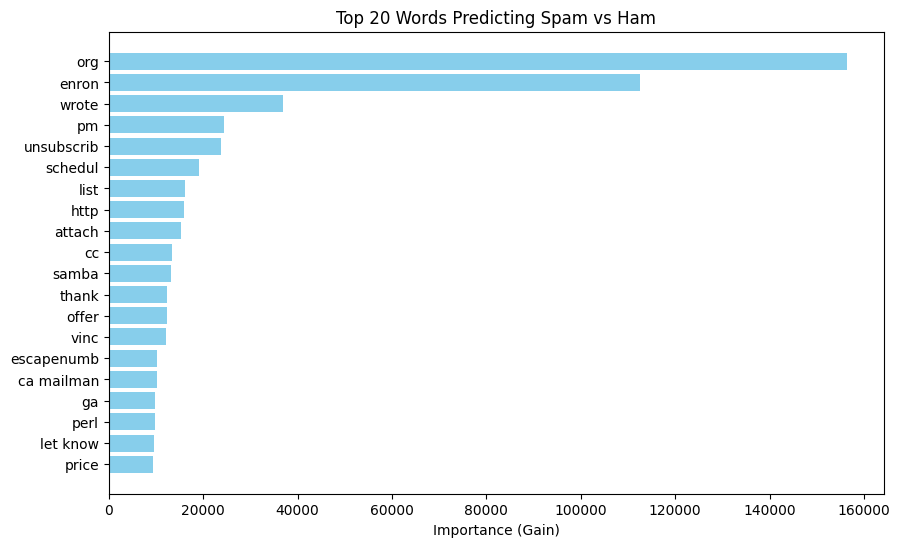

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Get feature importance
# importances = lgbm_model.feature_importances_
# feature_names = tfidf.get_feature_names_out()
# #
# # Create a DataFrame for visualization
# feature_importance_df = pd.DataFrame({'Word': feature_names, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# # Plot
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance_df['Word'], feature_importance_df['Importance'], color='skyblue')
# plt.xlabel('Importance (Gain)')
# plt.title('Top 20 Words Predicting Spam vs Ham')
# plt.gca().invert_yaxis()
# plt.show()

In [ ]:
# s="Hello deepashu how are you hope you are fine"

In [ ]:
# from nltk.stem import WordNetLemmatizer
# lemmatizer=WordNetLemmatizer()
# stop_words = set(stopwords.words('english'))
# corpus2 = []
# review = re.sub('[^a-zA-Z]', ' ', s)
# review = review.lower().split()
# review = [lemmatizer.lemmatize(word,pos='v') for word in review if not word in stop_words]
# review = ' '.join(review)
# corpus2.append(review)

In [ ]:
# (df['label']==0).sum()/(df['label']==1).sum()

np.float64(0.9004327032566614)

In [ ]:
# corpus2

['hello deepashu hope fine']

In [ ]:
# import lightgbm as lgb
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics import classification_report, accuracy_score

# # The tfidf vectorizer and lgbm_model were already fitted in cell 'vR_qNJMqk5TR'.
# # We should use that already fitted tfidf object to transform the new text.

# # Re-instantiate and re-fit TfidfVectorizer with the parameters used for training
# # This is necessary because the `tfidf` variable was overwritten or is in an inconsistent state.
# # In a real-world scenario, you would save and load the fitted vectorizer.
# tfidf_for_prediction = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
# tfidf_for_prediction.fit(corpus) # Fit on the full training corpus

# X_tfidf_for_prediction = tfidf_for_prediction.transform(corpus2)

# # 5. Predict and Evaluate
# y_pred_single_input = lgbm_model.predict(X_tfidf_for_prediction)
# y_pred_single_input

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([1])

### Inspecting Features for 'Hello deepashu how are you hope you are fine'

Let's look at the processed text and the specific TF-IDF features that are activated by this input, and then see their importance in our trained model.

In [ ]:
# # Get the TF-IDF representation of the input text
# X_single_input = tfidf_for_prediction.transform(corpus2)

# # Get the feature names corresponding to the non-zero elements in the input vector
# feature_indices = X_single_input.nonzero()[1]
# activated_feature_names = [tfidf_for_prediction.get_feature_names_out()[i] for i in feature_indices]

# # Get the importance of these activated features from the trained LightGBM model
# feature_importances = lgbm_model.feature_importances_
# activated_feature_importances = {name: feature_importances[tfidf_for_prediction.vocabulary_[name]] for name in activated_feature_names if name in tfidf_for_prediction.vocabulary_}

# print("Processed input text:", corpus2[0])
# print("\nActivated TF-IDF features and their importances:")
# for feature, importance in sorted(activated_feature_importances.items(), key=lambda item: item[1], reverse=True):
#     print(f"  - {feature}: {importance:.2f}")

# if not activated_feature_names:
#     print("No relevant features found in the input text that are part of the model's vocabulary.")

Processed input text: hello deepashu hope fine

Activated TF-IDF features and their importances:
  - hello: 837.01
  - hope: 197.44
  - fine: 31.60


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,df['label'],random_state=42,test_size=0.2)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
spam_detect_model=MultinomialNB().fit(x_train,y_train)
y_train_pred=spam_detect_model.predict(x_train)
y_test_pred=spam_detect_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_train,y_train_pred))
print(accuracy_score(y_test,y_test_pred))

0.9423889271697774
0.9463151587777112


In [ ]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      7938
           1       0.95      0.95      0.95      8752

    accuracy                           0.95     16690
   macro avg       0.95      0.95      0.95     16690
weighted avg       0.95      0.95      0.95     16690



In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=2500,ngram_range=(1,2))

In [28]:
X=tfidf.fit_transform(corpus).toarray()

In [29]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,df['label'],random_state=42,test_size=0.2)

In [31]:
from sklearn.naive_bayes import MultinomialNB
spam_detect=MultinomialNB().fit(x_train,y_train)
y_pred=spam_detect.predict(x_train)
y_t_pred=spam_detect.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_train,y_pred))
print(accuracy_score(y_test,y_t_pred))

0.9554510320860421
0.9580587177950869


In [33]:
print(classification_report(y_test,y_t_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7938
           1       0.96      0.97      0.96      8752

    accuracy                           0.96     16690
   macro avg       0.96      0.96      0.96     16690
weighted avg       0.96      0.96      0.96     16690



##Actual ml way
1. Clean and Preprocess
2. Train test split
3. BOW AND TF-IDF
4. TRAIN MODEL

In [51]:
y=df['label']

In [47]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [37]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
corpus1 = []

for i in range(0, df.shape[0]):
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    review = review.lower().split()
    # 2. Use the 'stop_words' variable here
    review = [lemmatizer.lemmatize(word,pos='v') for word in review if not word in stop_words]
    review = ' '.join(review)
    corpus1.append(review)

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(corpus1,y,random_state=42,test_size=0.2)

In [63]:
x_train

['hi send email last week need confirm everything please read info let know question accept mortgage application poor cr edit ok get loan month payment approval process take minute visit link fill short form http saserf info azwma best regard manager angelia pickett national equity group',
 'take request http use perl org petdance journal escapenumber xoxo andy andy lester andy petdance com www petdance com aim petdance',
 'escapenumber escapenumber escapenumber tony marquis write try read body attachment mime message keep get folling error use uninitialized value pattern match usr share perlescapenumber email mime contenttype pm line escapenumber mean near line escapenumber contenttype pm file pattern match either pattern string suppose match come variable variable hold undef perl get examine code around line escapenumber stop right point debugger might able tell miss good luck tom phoenix stonehenge perl train unsubscribe e mail beginners unsubscribe perl org additional command e mai

In [55]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=2500,binary=True,ngram_range=(1,2))
x_train=cv.fit_transform(x_train).toarray()
x_test=cv.transform(x_test).toarray()

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=2500,ngram_range=(1,2))

In [65]:
x_train=tfidf.fit_transform(x_train).toarray()
x_test=tfidf.transform(x_test).toarray()

In [66]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.07296482, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [67]:
from sklearn.naive_bayes import MultinomialNB
spam_detect=MultinomialNB().fit(x_train,y_train)
y_pred=spam_detect.predict(x_train)
y_t_pred=spam_detect.predict(x_test)

In [68]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_train,y_pred))
print(accuracy_score(y_test,y_t_pred))

0.9566493903352408
0.9579988016776513


In [69]:
print(classification_report(y_test,y_t_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7938
           1       0.95      0.97      0.96      8752

    accuracy                           0.96     16690
   macro avg       0.96      0.96      0.96     16690
weighted avg       0.96      0.96      0.96     16690

